# Multilabel UCM — Vision Transformer (ViT-B/16)

Mismo workflow que `00_ML_Resnet.ipynb` (misma seed=42, mismos splits estratificados, mismas métricas), pero el backbone es `vit_b_16` pre-entrenado en ImageNet.

**Cambios respecto a ResNet:**
- Backbone: `torchvision.models.vit_b_16` con weights `IMAGENET1K_V1`.
- LR más bajo (`3e-5`) y weight decay `0.05` — recomendado para fine-tuning de ViT.
- Nombres de checkpoints / logger / run de WandB distintos para no pisar los del ResNet.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

Working in: /content/drive/MyDrive/DL_Group_MGI1


In [4]:
# Install dependencies if not already installed
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 70.7 MB/s eta 0:00:00


In [5]:
# Run this everytime you update something in the repo!
import os

REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 25 (delta 16), reused 22 (delta 13), pack-reused 0 (from 0)
Unpacking objects: 100% (25/25), 2.52 MiB | 1.33 MiB/s, done.
From https://github.com/gabrielcastrob/Deep_learning_WUR
   ff6bed1..17d4698  main       -> origin/main
Updating ff6bed1..17d4698
Fast-forward
 notebooks/00_ML_Resnet.ipynb                   | 340 ++++++-----
 notebooks/01_ML_ViT.ipynb                      | 230 ++++++++
 notebooks/Level2_ResNet50_UCM_multilabel.ipynb | 784 ++++++++++++++-----------
 3 files changed, 856 insertions(+), 498 deletions(-)
 create mode 100644 notebooks/01_ML_ViT.ipynb
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


## Download dataset

In [6]:
"Download the UCMerced Land Use dataset if not already present."
"The dataset will be saved in the 'ucmdata' directory."

import os
import zipfile
import subprocess
import shutil

if not os.path.exists('ucmdata'):
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')
    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
        zip_ref.extractall('UCMImages')
    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    os.remove('README.md')
    os.remove('UCMerced_LandUse.zip')
    os.chdir(PROJECT_DIR)

print(os.listdir('.'))

['.git', 'GRS_34806_MGI_Project.ipynb', 'LICENSE', 'Level2_ResNet50_UCM', 'README.md', 'notebooks', 'ucmdata', 'outputs', 'wandb']


## Load Packages

In [18]:
import random, shutil, zipfile
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
import torchvision.models as tvm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import torchmetrics
import re

from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

# ⬇️ Misma semilla que en el notebook ResNet → mismos splits, mismos shuffles
L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: Tesla T4


## Class list and dataset

In [8]:
class UCMMultilabelDataset(Dataset):
    """UCM multilabel land-use dataset. Mismo comportamiento que el notebook ResNet."""

    def __init__(self, root_dir="ucmdata", label_file="LandUse_Multilabeled.txt",
                 transform=None, image_ext=".tif"):
        self.root_dir   = root_dir
        self.images_dir = os.path.join(root_dir, "Images")
        self.transform  = transform
        self.image_ext  = image_ext

        label_path = os.path.join(root_dir, label_file)
        self.class_names, self.label_matrix = self._parse_labels(label_path)
        self.num_classes = len(self.class_names)
        self.image_paths = self._collect_image_paths()

        assert len(self.image_paths) == len(self.label_matrix), (
            f"Mismatch: {len(self.image_paths)} images vs {len(self.label_matrix)} label rows.")

    def _parse_labels(self, label_path):
        with open(label_path, "r") as f:
            lines = [l.strip() for l in f if l.strip()]
        header = lines[0].split("\t")
        class_names = header[1:]
        rows = [list(map(int, line.split("\t")[1:])) for line in lines[1:]]
        label_matrix = torch.tensor(rows, dtype=torch.float32)
        return class_names, label_matrix

    def _collect_image_paths(self):
        image_paths = []
        subfolders = sorted(entry.name for entry in os.scandir(self.images_dir))
        for subfolder in subfolders:
            folder_path = os.path.join(self.images_dir, subfolder)
            files = sorted(fname for fname in os.listdir(folder_path)
                           if fname.lower().endswith(self.image_ext))
            for fname in files:
                image_paths.append(os.path.join(folder_path, fname))
        return image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        labels   = self.label_matrix[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, labels

    def get_class_names(self):
        return self.class_names

    def get_class_weights(self):
        pos = self.label_matrix.sum(dim=0).clamp(min=1)
        neg = (len(self) - self.label_matrix.sum(dim=0)).clamp(min=1)
        return neg / pos

## Augmentation

`vit_b_16` usa entrada 224×224, igual que ResNet-50 → no cambia nada.

In [9]:
IMAGE_SIZE = (224, 224)
def get_transforms(split="train"):
    if split == "train":
        return transforms.Compose([
            transforms.Resize(IMAGE_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(45),
            transforms.ColorJitter(brightness=0.2, contrast=0.4, saturation=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], # Imagenet stats (standard for imageNet pretraining)
                                 std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

## Data split (idéntico al ResNet, misma seed=42 → mismos índices)

In [10]:
def build_dataloaders(root_dir="ucmdata", label_file="LandUse_Multilabeled.txt",
                      batch_size=32, num_workers=4, val_frac=0.15, test_frac=0.15,
                      seed=42, image_ext=".tif"):
    full_ds = UCMMultilabelDataset(root_dir=root_dir, label_file=label_file,
                                   transform=None, image_ext=image_ext)
    n = len(full_ds)
    labels_array = full_ds.label_matrix.numpy()

    splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_frac, random_state=seed)
    train_val_idx, test_idx = next(splitter.split(np.zeros(n), labels_array))

    train_val_labels = labels_array[train_val_idx]
    val_frac_adjusted = val_frac / (1 - test_frac)
    splitter2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=val_frac_adjusted, random_state=seed)
    train_idx_local, val_idx_local = next(splitter2.split(np.zeros(len(train_val_idx)), train_val_labels))

    train_idx = train_val_idx[train_idx_local]
    val_idx   = train_val_idx[val_idx_local]

    def make_subset(split_name, indices):
        ds = UCMMultilabelDataset(root_dir=root_dir, label_file=label_file,
                                  transform=get_transforms(split_name), image_ext=image_ext)
        return Subset(ds, indices)

    train_ds = make_subset("train", train_idx)
    val_ds   = make_subset("val",   val_idx)
    test_ds  = make_subset("test",  test_idx)

    kw = dict(batch_size=batch_size, num_workers=num_workers,
              pin_memory=torch.cuda.is_available())
    return (
        DataLoader(train_ds, shuffle=True,  **kw),
        DataLoader(val_ds,   shuffle=True,  **kw),
        DataLoader(test_ds,  shuffle=False, **kw),
        full_ds.get_class_names(),
        full_ds.get_class_weights(),
    )

In [11]:
train_loader, val_loader, test_loader, classes, pos_w = build_dataloaders()

train_labels = torch.cat([labels for _, labels in train_loader]).numpy()
val_labels   = torch.cat([labels for _, labels in val_loader]).numpy()
test_labels  = torch.cat([labels for _, labels in test_loader]).numpy()

print("Train class freq:", train_labels.sum(axis=0))
print("Val   class freq:", val_labels.sum(axis=0))
print("Test  class freq:", test_labels.sum(axis=0))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train class freq: [ 70. 502. 483. 620.  81.  73.  70.  72. 682.  72. 903. 206.  70.  72.
  70. 706. 142.]
Val   class freq: [ 15. 108. 104. 133.  17.  16.  15.  16. 147.  15. 196.  44.  15.  15.
  15. 152.  31.]
Test  class freq: [ 15. 108. 104. 133.  17.  16.  15.  15. 146.  15. 201.  44.  15.  15.
  15. 151.  30.]


## Initialize WANDB

In [12]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abelchachoek (abelchachoek-wur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Hyperparameters (ajustados para ViT)

In [13]:
# ⬇️ Ajustes respecto a ResNet: LR más bajo y weight_decay más alto (recomendado para ViT)
PRETRAINED_MODEL = "vit_b_16"
NUM_CLASSES  = len(classes)
MAX_EPOCHS   = 15
LR           = 3e-5        # ResNet usaba 1e-4; ViT necesita LR más bajo
WEIGHT_DECAY = 5e-2        # ViT típicamente usa weight_decay mayor
run_count    = 1

## Log WandB

In [14]:
run = wandb.init(project="multilabel-classification",
                 name="ML_ptViT_b16_" + str(run_count),
                 config={
                     "pretrained_model": PRETRAINED_MODEL,
                     "classes": NUM_CLASSES,
                     "max_epochs": MAX_EPOCHS,
                     "learning_rate": LR,
                     "weight_decay": WEIGHT_DECAY,
                 })

## Build Vision Transformer

`torchvision.models.vit_b_16` con pesos ImageNet. La cabeza de clasificación está en `model.heads.head` (un `nn.Linear`). La reemplazamos por una nueva con `NUM_CLASSES` salidas.

In [15]:
def build_vit_b16(num_classes):
    weights = tvm.ViT_B_16_Weights.IMAGENET1K_V1
    model = tvm.vit_b_16(weights=weights)
    # La cabeza de ViT en torchvision es model.heads (Sequential) con head -> Linear(768, 1000)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model

backbone = build_vit_b16(num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f"ViT-B/16 trainable parameters: {n_params:,}  |  output logits: {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 161MB/s] 


ViT-B/16 trainable parameters: 85,811,729  |  output logits: 17


## LightningModule para ViT multilabel

Exactamente la misma lógica que `LitResNetMultilabel`: BCEWithLogitsLoss con `pos_weight`, F1 macro / acc / mAP como métricas, AdamW + CosineAnnealing.

In [16]:
class LitViTMultilabel(L.LightningModule):
    def __init__(self, model, num_classes, lr=3e-5, weight_decay=5e-2,
                 max_epochs=15, threshold=0.5, pos_weight=None):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        pos_weight = torch.as_tensor(pos_weight, dtype=torch.float32) if pos_weight is not None else None
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.threshold = threshold

        mk = dict(task="multilabel", num_labels=num_classes, threshold=threshold)
        self.train_f1 = torchmetrics.F1Score(average="macro", **mk)
        self.val_f1   = torchmetrics.F1Score(average="macro", **mk)
        self.test_f1  = torchmetrics.F1Score(average="macro", **mk)
        self.val_acc  = torchmetrics.Accuracy(average="macro", **mk)
        self.test_acc = torchmetrics.Accuracy(average="macro", **mk)
        self.val_map  = torchmetrics.AveragePrecision(task="multilabel", num_labels=num_classes, average="macro")
        self.test_map = torchmetrics.AveragePrecision(task="multilabel", num_labels=num_classes, average="macro")

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        imgs, labels = batch
        logits = self(imgs)
        loss = self.criterion(logits, labels)
        return loss, logits, labels

    def training_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.train_f1.update(logits, labels.int())
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_f1",   self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.val_f1.update(logits, labels.int())
        self.val_acc.update(logits, labels.int())
        self.val_map.update(logits, labels.int())
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_f1",   self.val_f1,  on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc",  self.val_acc, on_step=False, on_epoch=True)
        self.log("val_map",  self.val_map, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.test_f1.update(logits, labels.int())
        self.test_acc.update(logits, labels.int())
        self.test_map.update(logits, labels.int())
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log("test_f1",   self.test_f1,  on_step=False, on_epoch=True)
        self.log("test_acc",  self.test_acc, on_step=False, on_epoch=True)
        self.log("test_map",  self.test_map, on_step=False, on_epoch=True)

    def predict_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= self.threshold).int()
        return {"probs": probs, "preds": preds, "labels": labels.int()}

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(),
                                      lr=self.hparams.lr,
                                      weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs)
        return [optimizer], [scheduler]

## Training

In [19]:
lit_model = LitViTMultilabel(model=backbone, num_classes=NUM_CLASSES,
                             lr=LR, weight_decay=WEIGHT_DECAY,
                             max_epochs=MAX_EPOCHS, pos_weight=pos_w)

checkpoint_cb = ModelCheckpoint(
    dirpath="outputs/checkpoints",
    filename="vit_b16-multilabel-best-{epoch:02d}-{val_f1:.4f}",
    monitor="val_f1", mode="max", save_top_k=1, save_weights_only=True,
)

early_stop_cb = EarlyStopping(
    monitor="val_f1",   # misma métrica que monitorea el checkpoint
    mode="max",         # "max" porque queremos F1 lo más alto posible
    patience=5,         # espera 5 epochs sin mejora antes de parar
    min_delta=0.001,    # mejora mínima para considerarla "real"
    verbose=True,       # imprime un mensaje cuando para
)

csv_logger = CSVLogger(save_dir="outputs/logs", name="vit_b16_multilabel")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_cb, early_stop_cb],
    logger=csv_logger,
    log_every_n_steps=10,
)
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DE

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer          │ 85.8 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 160                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO: Metric val_f1 improved by 0.026 >= min_delta = 0.001. New best score: 0.920
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.026 >= min_delta = 0.001. New best score: 0.920


INFO: Metric val_f1 improved by 0.016 >= min_delta = 0.001. New best score: 0.936
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.016 >= min_delta = 0.001. New best score: 0.936


INFO: Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.938
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.938


INFO: Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.942
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.004 >= min_delta = 0.001. New best score: 0.942


INFO: Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.942. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.942. Signaling Trainer to stop.


## Final classification on test data

In [20]:
trainer.test(lit_model, dataloaders=test_loader, ckpt_path="best")

best_path = checkpoint_cb.best_model_path
print(f"Best checkpoint: {best_path}")
lit_model = LitViTMultilabel.load_from_checkpoint(best_path, model=lit_model.model)

preds_out = trainer.predict(lit_model, dataloaders=test_loader)
test_probs  = torch.cat([b["probs"]  for b in preds_out], dim=0).cpu().numpy()
test_preds  = torch.cat([b["preds"]  for b in preds_out], dim=0).cpu().numpy()
test_labels = torch.cat([b["labels"] for b in preds_out], dim=0).cpu().numpy()

from sklearn.metrics import f1_score, average_precision_score, hamming_loss

macro_f1   = f1_score(test_labels, test_preds, average="macro",   zero_division=0)
micro_f1   = f1_score(test_labels, test_preds, average="micro",   zero_division=0)
samples_f1 = f1_score(test_labels, test_preds, average="samples", zero_division=0)
macro_map  = average_precision_score(test_labels, test_probs, average="macro")
hamming    = hamming_loss(test_labels, test_preds)
subset_acc = (test_preds == test_labels).all(axis=1).mean()

print(f"\nTest macro F1   : {macro_f1:.4f}")
print(f"Test micro F1   : {micro_f1:.4f}")
print(f"Test samples F1 : {samples_f1:.4f}")
print(f"Test macro mAP  : {macro_map:.4f}")
print(f"Hamming loss    : {hamming:.4f}")
print(f"Exact-match acc : {subset_acc:.4f}")

INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vit_b16-multilabel-best-epoch=12-val_f1=0.9430.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vit_b16-multilabel-best-epoch=12-val_f1=0.9430.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vit_b16-multilabel-best-epoch=12-val_f1=0.9430.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vit_b16-multilabel-best-epoch=12-val_f1=0.9430.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9610340595245361     │
│          test_f1          │    0.9408575892448425     │
│         test_loss         │    0.1524597704410553     │
│         test_map          │    0.9829162359237671     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vit_b16-multilabel-best-epoch=12-val_f1=0.9430.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Output()


Test macro F1   : 0.9409
Test micro F1   : 0.9054
Test samples F1 : 0.9098
Test macro mAP  : 0.9829
Hamming loss    : 0.0390
Exact-match acc : 0.5382


## Log Results

In [21]:
run.log({"macro_f1": macro_f1, "micro_f1": micro_f1, "samples_f1": samples_f1,
         "macro_map": macro_map, "hamming_loss": hamming, "subset_acc": subset_acc})
run.finish()

hamming_loss,▁
macro_f1,▁
macro_map,▁
micro_f1,▁
samples_f1,▁
subset_acc,▁
hamming_loss,0.03897
macro_f1,0.94086
macro_map,0.98292
micro_f1,0.90537
samples_f1,0.90984


## Visualize learning curves

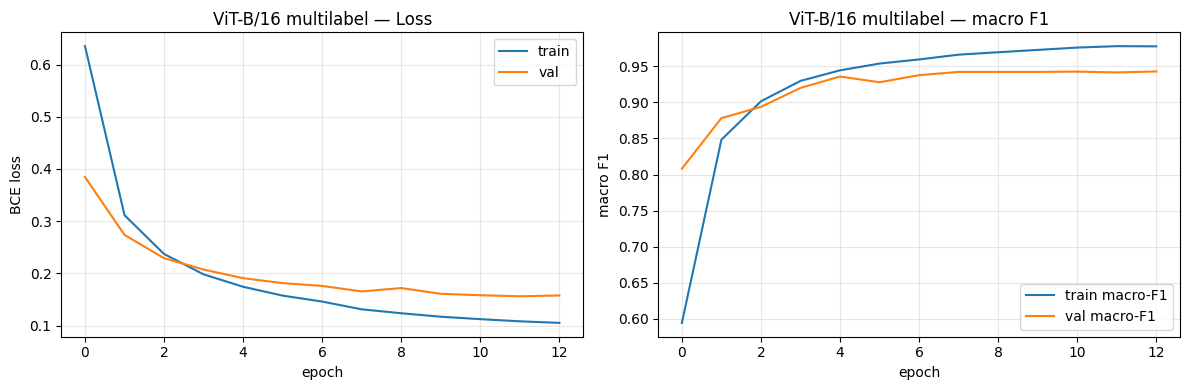

In [22]:
metrics_csv = Path(csv_logger.log_dir) / "metrics.csv"
df = pd.read_csv(metrics_csv)
epoch_df = df.groupby("epoch").mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if "train_loss" in epoch_df:
    axes[0].plot(epoch_df["epoch"], epoch_df["train_loss"], label="train")
if "val_loss" in epoch_df:
    axes[0].plot(epoch_df["epoch"], epoch_df["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("ViT-B/16 multilabel — Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

if "train_f1" in epoch_df:
    axes[1].plot(epoch_df["epoch"], epoch_df["train_f1"], label="train macro-F1")
if "val_f1" in epoch_df:
    axes[1].plot(epoch_df["epoch"], epoch_df["val_f1"], label="val macro-F1")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro F1")
axes[1].set_title("ViT-B/16 multilabel — macro F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
Path("outputs").mkdir(exist_ok=True)
plt.savefig("outputs/vit_b16_multilabel_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## F1 AND mAP score per class

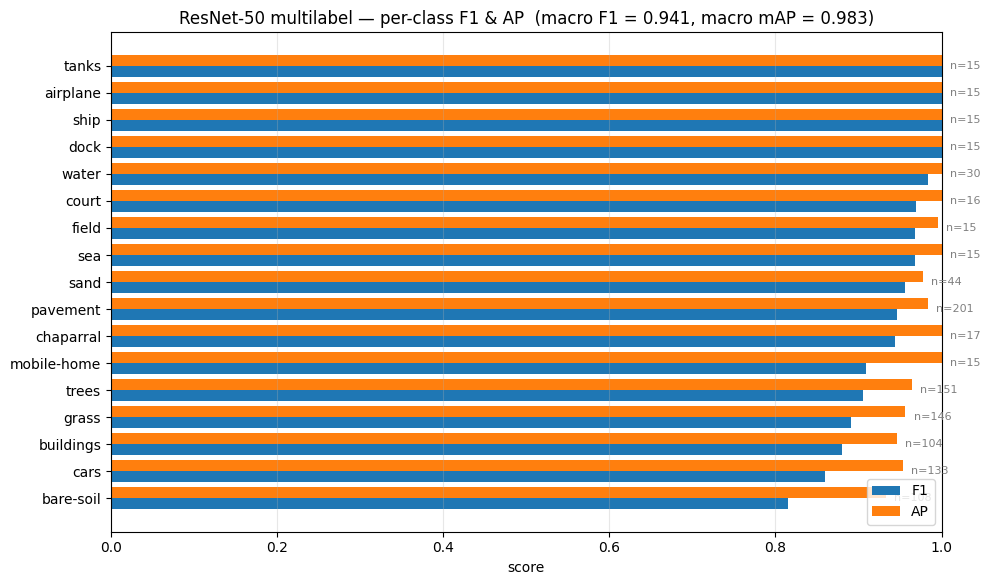

      class  positives     F1     AP
   airplane         15 1.0000 1.0000
       dock         15 1.0000 1.0000
      tanks         15 1.0000 1.0000
       ship         15 1.0000 1.0000
      water         30 0.9836 1.0000
      court         16 0.9697 1.0000
        sea         15 0.9677 1.0000
      field         15 0.9677 0.9958
       sand         44 0.9556 0.9777
   pavement        201 0.9469 0.9834
  chaparral         17 0.9444 1.0000
mobile-home         15 0.9091 1.0000
      trees        151 0.9049 0.9645
      grass        146 0.8904 0.9562
  buildings        104 0.8796 0.9464
       cars        133 0.8601 0.9530
  bare-soil        108 0.8148 0.9325

All outputs saved to: /content/drive/MyDrive/DL_Group_MGI1/outputs


In [25]:
per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
per_class_ap = average_precision_score(test_labels, test_probs, average=None)
positives    = test_labels.sum(axis=0).astype(int)

order = np.argsort(per_class_f1)   # ascending, so weakest classes show first
classes_sorted = [classes[i] for i in order]
f1_sorted  = per_class_f1[order]
ap_sorted  = per_class_ap[order]
pos_sorted = positives[order]

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * NUM_CLASSES)))
y = np.arange(NUM_CLASSES)
ax.barh(y - 0.2, f1_sorted, height=0.4, label="F1")
ax.barh(y + 0.2, ap_sorted, height=0.4, label="AP")
ax.set_yticks(y); ax.set_yticklabels(classes_sorted)
ax.set_xlim(0, 1)
ax.set_xlabel("score")
ax.set_title(f"ResNet-50 multilabel — per-class F1 & AP  (macro F1 = {macro_f1:.3f}, macro mAP = {macro_map:.3f})")
for i, (f, a, p) in enumerate(zip(f1_sorted, ap_sorted, pos_sorted)):
    ax.text(max(f, a) + 0.01, i, f"n={p}", va="center", fontsize=8, color="gray")
ax.legend(loc="lower right"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/resnet50_multilabel_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-class summary table
summary = pd.DataFrame({
    "class": classes,
    "positives": positives,
    "F1":  per_class_f1.round(4),
    "AP":  per_class_ap.round(4),
}).sort_values("F1", ascending=False)
print(summary.to_string(index=False))
summary.to_csv("outputs/resnet50_multilabel_per_class.csv", index=False)
print("\nAll outputs saved to:", Path("outputs").resolve())

## Examples of images (GT vs predicción)

In [ ]:
test_ds_full   = UCMMultilabelDataset(root_dir="ucmdata", label_file="LandUse_Multilabeled.txt", transform=None)
test_ds_subset = test_loader.dataset
test_indices   = test_ds_subset.indices
test_items     = [(test_ds_full.image_paths[idx], None) for idx in test_indices]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

N_SHOW = 9
COLS   = 3
ROWS   = (N_SHOW + COLS - 1) // COLS

errors_per_sample = (test_preds != test_labels).sum(axis=1)
correct_idx = np.where(errors_per_sample == 0)[0]
wrong_idx   = np.where(errors_per_sample >  0)[0]

rng_show = np.random.default_rng(0)
n_correct = min(N_SHOW // 2, len(correct_idx))
n_wrong   = N_SHOW - n_correct
chosen = np.concatenate([
    rng_show.choice(correct_idx, n_correct, replace=False),
    rng_show.choice(wrong_idx,   n_wrong,   replace=False),
])
rng_show.shuffle(chosen)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 4.5, ROWS * 5.2))
axes = axes.flatten()

for ax, sample_i in zip(axes, chosen):
    rel_path, _ = test_items[sample_i]
    img = Image.open(rel_path).convert("RGB")
    ax.imshow(img); ax.axis("off")

    gt   = test_labels[sample_i].astype(bool)
    pred = test_preds[sample_i].astype(bool)
    probs = test_probs[sample_i]
    tp = gt &  pred
    fp = ~gt &  pred
    fn = gt  & ~pred

    fname = Path(rel_path).name
    ax.set_title(f"{fname}\nTP={tp.sum()}  FP={fp.sum()}  FN={fn.sum()}",
                 fontsize=10, loc="left")

    lines = []
    for i in np.where(tp)[0]:
        lines.append(("green",  f"\u2713 {classes[i]}  ({probs[i]:.2f})"))
    for i in np.where(fn)[0]:
        lines.append(("red",    f"\u2717 {classes[i]}  ({probs[i]:.2f})  [missed]"))
    for i in np.where(fp)[0]:
        lines.append(("orange", f"+ {classes[i]}  ({probs[i]:.2f})  [extra]"))
    for j, (color, text) in enumerate(lines):
        ax.text(0.0, -0.04 - 0.06 * j, text, transform=ax.transAxes,
                fontsize=9, color=color, va="top", ha="left", family="monospace")

for ax in axes[len(chosen):]:
    ax.axis("off")

legend_handles = [
    mpatches.Patch(color="green",  label="TP — correctly predicted"),
    mpatches.Patch(color="red",    label="FN — missed (in GT, not predicted)"),
    mpatches.Patch(color="orange", label="FP — extra (predicted, not in GT)"),
]
fig.legend(handles=legend_handles, loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

Code tested 